In [1]:
import os
import numpy as np
import pandas as pd
import scipy
import time
import random
import math
import torch
import scanpy as sc
from scipy.sparse import issparse
from torch.utils.data import Dataset
from anndata import AnnData
from glob import glob
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init
from itertools import repeat
from torch.utils.data.sampler import Sampler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import maxabs_scale, MaxAbsScaler
from sklearn.mixture import GaussianMixture
from scipy.sparse import csc_matrix
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import MultiStepLR, ExponentialLR, ReduceLROnPlateau
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
class EarlyStopping:
    def __init__(self, patience=10, verbose=False, outdir=None):
    
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.loss_min = np.inf
        self.model_file = os.path.join(outdir, 'model.pt') if outdir else None

    def __call__(self, loss, model):
        if np.isnan(loss):
            self.early_stop = True
        score = -loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(loss, model)
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                model.load_model(self.model_file)
        else:
            self.best_score = score
            self.save_checkpoint(loss, model)
            self.counter = 0

    def save_checkpoint(self, loss, model):
        if self.verbose:
            print(f'Loss decreased ({self.loss_min:.6f} --> {loss:.6f}).  Saving model ...')
        if self.model_file:
            torch.save(model.state_dict(), self.model_file)
        self.loss_min = loss

In [3]:
def compute_elbo(recon_x, x, gamma, c_params, z_params, binary=True):
    mu_c, var_c, pi = c_params  
    var_c += 1e-8
    n_centroids = pi.size(1)
    mu, logvar = z_params
    mu_expand = mu.unsqueeze(2).expand(mu.size(0), mu.size(1), n_centroids)
    logvar_expand = logvar.unsqueeze(2).expand(logvar.size(0), logvar.size(1), n_centroids)

    if binary:
        likelihood = -binary_cross_entropy(recon_x, x)  
    else:
        likelihood = -F.mse_loss(recon_x, x)

    logpzc = -0.5 * torch.sum(gamma * torch.sum(math.log(2 * math.pi) + \
                                                torch.log(var_c) + \
                                                torch.exp(logvar_expand) / var_c + \
                                                (mu_expand - mu_c) ** 2 / var_c, dim=1), dim=1)

    logpc = torch.sum(gamma * torch.log(pi), 1)

    qentropy = -0.5 * torch.sum(1 + logvar + math.log(2 * math.pi), 1)

    logqcx = torch.sum(gamma * torch.log(gamma), 1)

    kld = -logpzc - logpc + qentropy + logqcx

    return torch.sum(likelihood), torch.sum(kld)


In [4]:
def compute_kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

def compute_elbo_loss(recon_x, x, z_params, binary=True):
    mu, logvar = z_params
    kld = compute_kl_divergence(mu, logvar)
    if binary:
        likelihood = -binary_cross_entropy_loss(recon_x, x)
    else:
        likelihood = -F.mse_loss(recon_x, x)
    return torch.sum(likelihood), torch.sum(kld)

def binary_cross_entropy_loss(recon_x, x):
    return -torch.sum(x * torch.log(recon_x + 1e-8) + (1 - x) * torch.log(1 - recon_x + 1e-8), dim=-1)


In [23]:
def create_mlp(layers, activation=nn.ReLU(), bn=False, dropout=0):
    net = []
    for i in range(1, len(layers)):
        net.append(nn.Linear(layers[i-1], layers[i]))
        if bn:
            net.append(nn.BatchNorm1d(layers[i]))
        net.append(activation)
        if dropout > 0:
            net.append(nn.Dropout(dropout))
    return nn.Sequential(*net)


In [24]:
class Encoder(nn.Module):
    def __init__(self, dims, bn=False, dropout=0):

        super(Encoder, self).__init__()

        [x_dim, h_dim, z_dim] = dims
        self.hidden = create_mlp([x_dim]+h_dim, bn=bn, dropout=dropout)
        self.sample = GaussianSample(([x_dim]+h_dim)[-1], z_dim)

    def forward(self, x):
        x = self.hidden(x)
        return self.sample(x)


class Decoder(nn.Module):
    def __init__(self, dims, bn=False, dropout=0, output_activation=nn.Sigmoid()):

        super(Decoder, self).__init__()

        [z_dim, h_dim, x_dim] = dims

        self.hidden = create_mlp([z_dim, *h_dim], bn=bn, dropout=dropout)
        self.reconstruction = nn.Linear([z_dim, *h_dim][-1], x_dim)

        self.output_activation = output_activation

    def forward(self, x):
        x = self.hidden(x)
        if self.output_activation is not None:
            return self.output_activation(self.reconstruction(x))
        else:
            return self.reconstruction(x)

class DeterministicWarmup(object):

    def __init__(self, n=100, t_max=1):
        self.t = 0
        self.t_max = t_max
        self.inc = 1/n

    def __iter__(self):
        return self

    def __next__(self):
        t = self.t + self.inc

        self.t = self.t_max if t > self.t_max else t
        return self.t

    def next(self):
        t = self.t + self.inc

        self.t = self.t_max if t > self.t_max else t
        return self.t

In [25]:
class Stochastic(nn.Module):

    def reparametrize(self, mu, logvar):
        epsilon = torch.randn(mu.size(), requires_grad=False, device=mu.device)
        std = logvar.mul(0.5).exp_()
        z = mu.addcmul(std, epsilon)

        return z

In [26]:
class GaussianSample(Stochastic):

    def __init__(self, in_features, out_features):
        super(GaussianSample, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.mu = nn.Linear(in_features, out_features)
        self.log_var = nn.Linear(in_features, out_features)

    def forward(self, x):
        mu = self.mu(x)
        log_var = self.log_var(x)

        return self.reparametrize(mu, log_var), mu/10, log_var

In [44]:
class VAE(nn.Module):
    def __init__(self, dims, bn=False, dropout=0, binary=False):
        super(VAE, self).__init__()
        [x_dim, z_dim, encode_dim, decode_dim] = dims
        self.binary = binary
        if binary:
            decode_activation = nn.Sigmoid()
        else:
            decode_activation = None

        self.encoder = Encoder([x_dim, encode_dim, z_dim], bn=bn, dropout=dropout)
        self.decoder = Decoder([z_dim, decode_dim, x_dim], bn=bn, dropout=dropout, output_activation=decode_activation)

        self.initialize_weights()

    def initialize_weights(self):
        """Initialize weights for the linear layers in the network."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    m.bias.data.zero_()

    def forward(self, x, y=None):
        """Forward pass to encode input and reconstruct."""
        z, mu, logvar = self.encoder(x)
        recon_x = self.decoder(z)
        return recon_x

    def compute_loss(self, x):
        """Compute the reconstruction loss and KL divergence loss."""
        z, mu, logvar = self.encoder(x)
        recon_x = self.decoder(z)
        likelihood, kl_loss = compute_elbo_loss(recon_x, x, (mu, logvar), binary=self.binary)
        return (-likelihood, kl_loss)

    def train_model(self, dataloader,
                    lr=0.002,
                    weight_decay=5e-4,
                    device='cuda',
                    beta=1,
                    warmup_steps=200,
                    max_iter=30000,
                    verbose=True,
                    patience=100,
                    outdir=None):
        """Train the VAE model with the specified parameters."""
        self.to(device)
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        beta_scheduler = DeterministicWarmup(n=warmup_steps, t_max=beta)

        iteration = 0
        n_epoch = int(np.ceil(max_iter / len(dataloader)))
        early_stopping = EarlyStopping(patience=patience, outdir=outdir)

        for epoch in range(n_epoch):
            epoch_recon_loss, epoch_kl_loss = 0, 0
            for i, x in enumerate(dataloader):
                x = x.float().to(device)
                optimizer.zero_grad()

                recon_loss, kl_loss = self.compute_loss(x)
                loss = (recon_loss + kl_loss) / len(x)
                loss.backward()
                torch.nn.utils.clip_grad_norm(self.parameters(), 10)  # Clip gradients
                optimizer.step()

                epoch_kl_loss += kl_loss.item()
                epoch_recon_loss += recon_loss.item()

                iteration += 1

    def encode_batch(self, dataloader, device='cpu', output_type='z', transforms=None):
        """Encode a batch of data and return the specified output."""
        output = []
        for x in dataloader:
            x = x.view(x.size(0), -1).float().to(device)
            z, mu, logvar = self.encoder(x)

            if output_type == 'z':
                output.append(z.detach().cpu())
            elif output_type == 'x':
                recon_x = self.decoder(z)
                output.append(recon_x.detach().cpu().data)
            elif output_type == 'logit':
                output.append(self.get_gamma(z)[0].cpu().detach().data)
            elif output_type == 'mu':
                output.append(mu.cpu().detach().data)
            elif output_type == 'log_var':
                output.append(logvar.cpu().detach().data)

        output = torch.cat(output).numpy()
        return output


In [49]:
class PhytoCluster(VAE):
    def __init__(self, dims, n_centroids):
        super(PhytoCluster, self).__init__(dims)
        self.n_centroids = n_centroids
        z_dim = dims[1]

        # Initialize cluster parameters
        self.pi = nn.Parameter(torch.ones(n_centroids) / n_centroids)  # Cluster probabilities (pi)
        self.mu_c = nn.Parameter(torch.zeros(z_dim, n_centroids))  # Cluster means (mu)
        self.var_c = nn.Parameter(torch.ones(z_dim, n_centroids))  # Cluster variances (sigma^2)

    def compute_loss(self, x):
        """Compute the reconstruction loss and KL divergence with clustering."""
        z, mu, logvar = self.encoder(x)
        recon_x = self.decoder(z)
        gamma, mu_c, var_c, pi = self.infer_clusters(z)  # Get cluster assignments and parameters
        likelihood, kl_loss = compute_elbo(recon_x, x, gamma, (mu_c, var_c, pi), (mu, logvar), binary=self.binary)
        return -likelihood, kl_loss

    def infer_clusters(self, z):
        """
        Infer cluster assignments (gamma) based on latent variables z.
        gamma is q(c|x) where q(c|x) = p(c)p(z|c)/p(z).
        """
        n_centroids = self.n_centroids
        N = z.size(0)
        z = z.unsqueeze(2).expand(z.size(0), z.size(1), n_centroids)
        pi = self.pi.repeat(N, 1)  # NxK
        mu_c = self.mu_c.repeat(N, 1, 1)  # NxDxK
        var_c = self.var_c.repeat(N, 1, 1) + 1e-8  # NxDxK

        p_c_z = torch.exp(
            torch.log(pi) - torch.sum(0.5 * torch.log(2 * math.pi * var_c) + (z - mu_c) ** 2 / (2 * var_c),
                                      dim=1)) + 1e-10
        gamma = p_c_z / torch.sum(p_c_z, dim=1, keepdim=True)

        return gamma, mu_c, var_c, pi

    def initialize_gmm_params(self, dataloader, device='cpu'):
        """Initialize GMM parameters (means and variances) using latent variables."""
        gmm = GaussianMixture(n_components=self.n_centroids, covariance_type='diag')
        z = self.encode_batch(dataloader, device)
        gmm.fit(z)
        self.mu_c.data.copy_(torch.from_numpy(gmm.means_.T.astype(np.float32)))
        self.var_c.data.copy_(torch.from_numpy(gmm.covariances_.T.astype(np.float32)))


In [31]:
def fit(model,
        dataloader,
        lr=0.0002,
        var_lr=0.0002,
        weight_decay=5e-4,
        device='cuda',
        beta=1,
        n=2000,
        max_iter=30000,
        verbose=True,
        patience=100,
        outdir=None,
        ):
    self = model
    model.to(device)
    optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
    if isinstance(self, VAE):
        optimizer = torch.optim.Adam([{'params': self.encoder.hidden.parameters(), 'lr': lr},
                                      {'params': self.encoder.sample.mu.parameters(), 'lr': lr},
                                      {'params': self.encoder.sample.log_var.parameters(), 'lr': var_lr},
                                      {"params": self.decoder.parameters(), 'lr': lr}],
                                     weight_decay=weight_decay)

    Beta = DeterministicWarmup(n=n, t_max=beta)

    iteration = 0
    n_epoch = int(np.ceil(max_iter / len(dataloader)))
    early_stopping = EarlyStopping(patience=patience, outdir=outdir)
    kl_loss_hist = []
    rec_loss_hist = []
    loss_hist = []
    for epoch in tqdm(range(n_epoch)):
        epoch_recon_loss, epoch_kl_loss, epoch_loss = 0, 0, 0
        
        for i, x in enumerate(dataloader):
            x = x.float().to(device)
            optimizer.zero_grad()

            recon_loss, kl_loss = self.compute_loss(x)

            loss = recon_loss + next(Beta)*kl_loss
            if torch.isnan(loss):
                return
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.parameters(), 10)  # clip
            optimizer.step()

            epoch_kl_loss += kl_loss.item()/len(x)
            epoch_recon_loss += recon_loss.item()/len(x)
            epoch_loss += loss.item()/len(x)



            iteration += 1
        loss_hist.append(epoch_loss)
        kl_loss_hist.append(epoch_kl_loss)
        rec_loss_hist.append(epoch_recon_loss)


    fig, axes = plt.subplots(1, 3, figsize=(4*3, 4*1), layout='constrained')
    axes[0].plot(loss_hist, label='loss')
    axes[0].set_title(f'loss:{loss_hist[-1]}')
    axes[1].plot(rec_loss_hist, label='rec loss')
    axes[1].set_title(f'rec loss:{rec_loss_hist[-1]}')
    axes[2].plot(kl_loss_hist, label='kl loss')
    axes[2].set_title(f'kl loss:{kl_loss_hist[-1]}')
    plt.show()

In [18]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

In [62]:
if torch.cuda.is_available():  # cuda device
    device = 'cuda'
    torch.cuda.set_device(0)
    print(1)
else:
    device = 'cpu'

data_dir = "./"
data = pd.read_csv(os.path.join(data_dir, "test.csv"))
adata = sc.AnnData(data.iloc[:, 1:], obs=data.iloc[:,:1].astype('category'))
n_clusters = len(np.unique(adata.obs['label']))

n_top_genes = 3000
target_sum = 1000

sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=10000)
adata = adata[:, adata.var['highly_variable_rank']<n_top_genes]
sc.pp.normalize_total(adata, target_sum=target_sum)
sc.pp.log1p(adata)
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=50)

1


/home/wh/anaconda3/envs/dem/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/wh/anaconda3/envs/dem/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


100%|██████████| 653/653 [02:27<00:00,  4.44it/s]


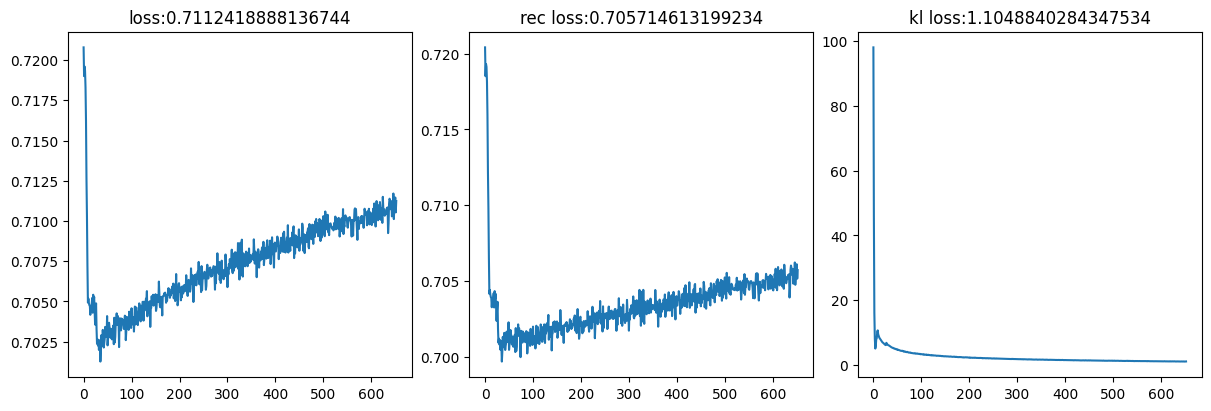

In [63]:
bn = False
dropout = 0
verbose = False
max_iter = 30000
outdir = None
lr = 0.0001

latent = 10
encode_dim = [1024, 128]
decode_dim = [128, 1024]
k = n_clusters

all_data_tensor = torch.from_numpy(adata.X).float()
dataloader = DataLoader(all_data_tensor, batch_size=64, drop_last=False, shuffle=False)
train_data_loader = DataLoader(all_data_tensor, batch_size=64, drop_last=True, shuffle=True)
input_dim = all_data_tensor.shape[-1]
dims = [input_dim, latent, encode_dim, decode_dim]
pretrain_model = VAE(dims, binary=False)

fit(pretrain_model, train_data_loader,
                    lr=lr,
                    var_lr=lr,
                    max_iter=max_iter,
                    verbose=verbose,
                    device=device,
                    outdir=outdir,
                    n=max_iter*200,
                  )

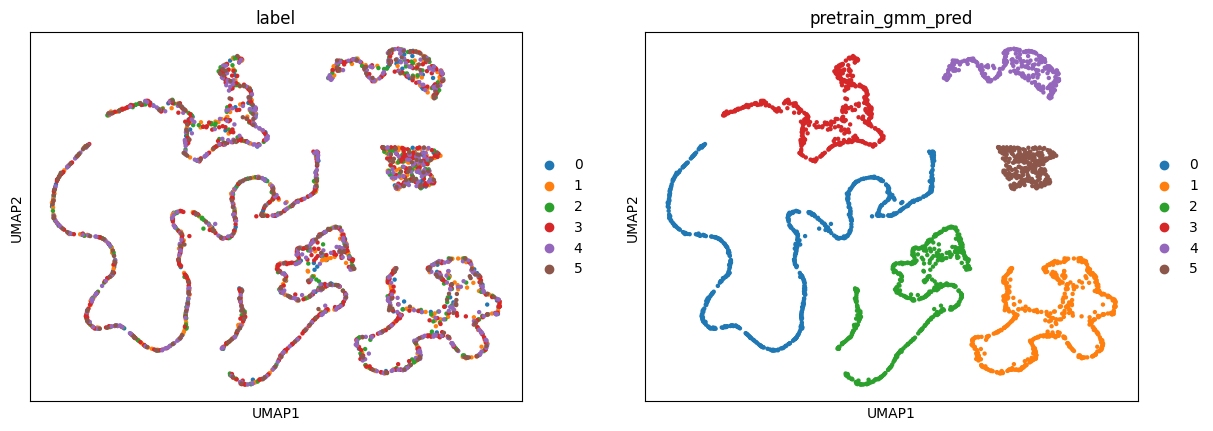

In [64]:
pretrain_model.eval()
pretrain_feat = pretrain_model.encode_batch(dataloader, device=device, output_type='mu')
pretrain_pred = GaussianMixture(n_components=k, covariance_type='diag').fit_predict(pretrain_feat)
adata.obs['pretrain_gmm_pred'] = pretrain_pred
adata.obs['pretrain_gmm_pred'] = adata.obs['pretrain_gmm_pred'].astype(int).astype('category')
data = sc.AnnData(pretrain_feat, obs=adata.obs)
sc.pp.neighbors(data)
sc.tl.umap(data)
sc.pl.umap(data, color=['label', 'pretrain_gmm_pred'])

100%|██████████| 7/7 [00:02<00:00,  2.82it/s]


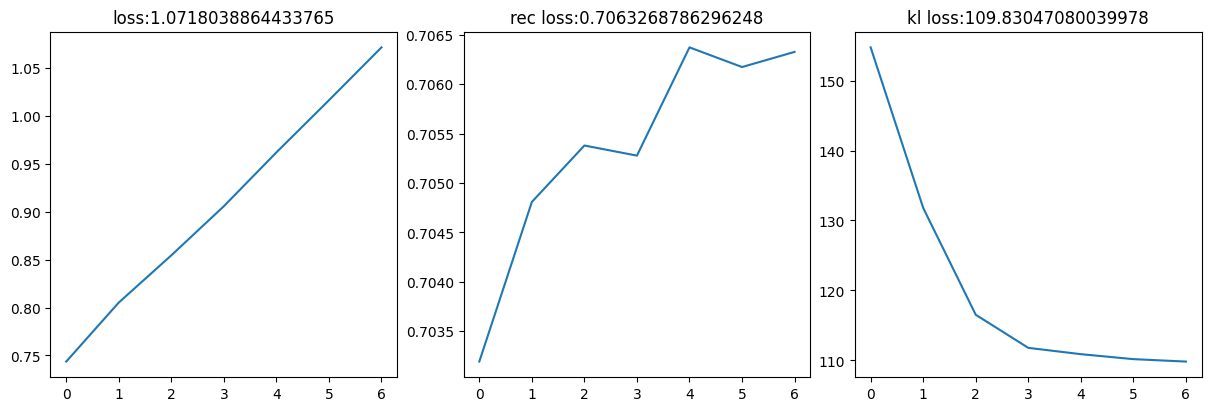

In [65]:
model = PhytoCluster(dims, n_clusters)
model.load_state_dict(pretrain_model.state_dict(), strict=False)
model.initialize_gmm_params(dataloader)
max_iter = 300
fit(model, train_data_loader,
                    lr=lr,
                    var_lr=lr,
                    max_iter=max_iter,
                    verbose=verbose,
                    device=device,
                    outdir=outdir,
                    n=max_iter*300,
                  )

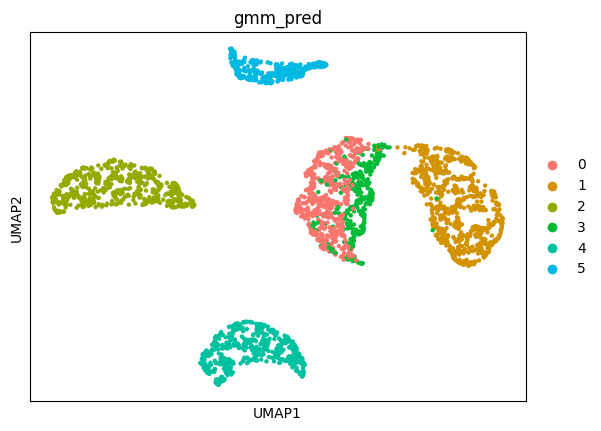

In [69]:
model.eval()
feat = model.encode_batch(dataloader, device=device, output_type='mu')
pred = GaussianMixture(n_components=k, covariance_type='diag').fit_predict(pretrain_feat)
adata.obs['gmm_pred'] = pred
adata.obs['gmm_pred'] = adata.obs['gmm_pred'].astype(int).astype('category')
data = sc.AnnData(feat, obs=adata.obs)
sc.pp.neighbors(data)
sc.tl.umap(data, min_dist=0.3)
custom_palette = ['#F8766D', '#D39200', '#93AA00', '#00BA38', '#00C19F', '#00B9E3']
sc.pl.umap(data, color=['gmm_pred'], palette=custom_palette)